In [1]:
import torch 
print(torch.cuda.is_available())       
print(torch.cuda.get_device_name(0))   

True
NVIDIA GeForce RTX 2050


In [2]:
import sys
!{sys.executable} -m pip install torch torchvision matplotlib seaborn pillow tqdm scikit-learn --quiet
print('✅ All libraries installed successfully!')

✅ All libraries installed successfully!


In [3]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [4]:
CONFIG = {
    'data_dir'   : 'cell_images',    
    'model_path' : 'malaria_model.pth', 

    'batch_size' : 32,
    'num_epochs' : 10,
    'lr'         : 1e-4,
    'img_size'   : 224,

    'val_split'  : 0.15,  
    'test_split' : 0.10,   
    'num_workers': 0,     
    'device'     : 'cuda' if torch.cuda.is_available() else 'cpu',
}

print(f"✅ Configuration ready!")
print(f"   Device     : {CONFIG['device']}")
print(f"   Image size : {CONFIG['img_size']}x{CONFIG['img_size']}")
print(f"   Batch size : {CONFIG['batch_size']}")
print(f"   Epochs     : {CONFIG['num_epochs']}")

✅ Configuration ready!
   Device     : cuda
   Image size : 224x224
   Batch size : 32
   Epochs     : 10


In [5]:
data_dir = CONFIG['data_dir']

if not os.path.exists(data_dir):
    print(f"❌ ERROR: '{data_dir}' folder not found!")
    print(f"   Please place your cell_images folder in the same directory as this notebook.")
else:
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    print(f"✅ Dataset folder found: ./{data_dir}/")
    print(f"   Classes found: {classes}")
    for cls in classes:
        count = len(os.listdir(os.path.join(data_dir, cls)))
        print(f"   {cls:15s} → {count:,} images")

✅ Dataset folder found: ./cell_images/
   Classes found: ['Parasitized', 'Uninfected']
   Parasitized     → 13,780 images
   Uninfected      → 13,780 images


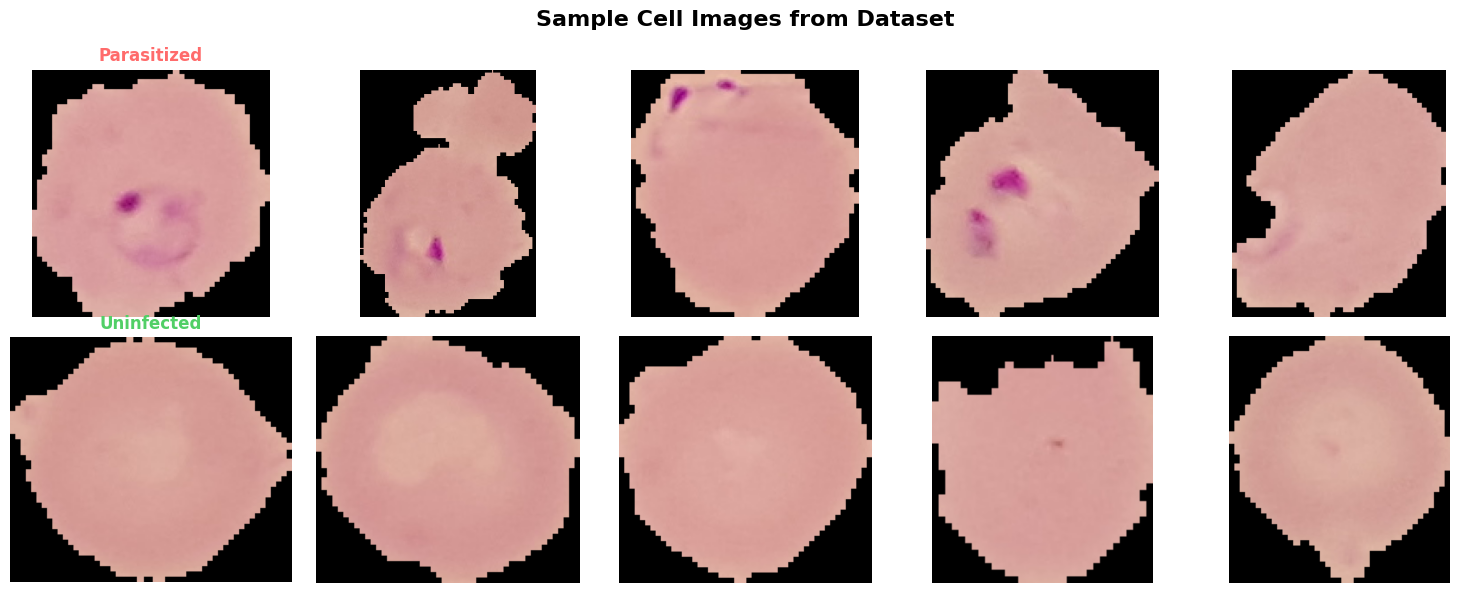

✅ Sample images displayed!


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Cell Images from Dataset', fontsize=16, fontweight='bold')

classes_list = ['Parasitized', 'Uninfected']
colors       = ['#ff6b6b', '#51cf66']

for row, (cls, color) in enumerate(zip(classes_list, colors)):
    folder = os.path.join(CONFIG['data_dir'], cls)
    images = [f for f in os.listdir(folder) if f.endswith(('.png', '.jpg', '.jpeg'))][:5]
    for col, img_file in enumerate(images):
        img = Image.open(os.path.join(folder, img_file)).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, color=color, fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images displayed!')

In [7]:
mean = [0.485, 0.456, 0.406]   
std  = [0.229, 0.224, 0.225]   
s    = CONFIG['img_size']

train_transforms = transforms.Compose([
    transforms.Resize((s, s)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_transforms = transforms.Compose([
    transforms.Resize((s, s)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

print('✅ Transforms defined!')
print('   Train transforms : Resize → Flip → Rotate → ColorJitter → Normalize')
print('   Val transforms   : Resize → Normalize')

✅ Transforms defined!
   Train transforms : Resize → Flip → Rotate → ColorJitter → Normalize
   Val transforms   : Resize → Normalize


In [8]:
full_dataset = datasets.ImageFolder(CONFIG['data_dir'], transform=train_transforms)
classes      = full_dataset.classes

n       = len(full_dataset)
n_val   = int(n * CONFIG['val_split'])
n_test  = int(n * CONFIG['test_split'])
n_train = n - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

val_ds.dataset        = copy.deepcopy(full_dataset)
test_ds.dataset       = copy.deepcopy(full_dataset)
val_ds.dataset.transform  = val_transforms
test_ds.dataset.transform = val_transforms

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=CONFIG['num_workers'])
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])

loaders = {'train': train_loader, 'val': val_loader, 'test': test_loader}
sizes   = {'train': n_train, 'val': n_val, 'test': n_test}

print(f'✅ Dataset loaded and split!')
print(f'   Classes  : {classes}')
print(f'   Total    : {n:,} images')
print(f'   Train    : {n_train:,} images ({100*(1-CONFIG["val_split"]-CONFIG["test_split"]):.0f}%)')
print(f'   Val      : {n_val:,} images ({100*CONFIG["val_split"]:.0f}%)')
print(f'   Test     : {n_test:,} images ({100*CONFIG["test_split"]:.0f}%)')

✅ Dataset loaded and split!
   Classes  : ['Parasitized', 'Uninfected']
   Total    : 27,558 images
   Train    : 20,670 images (75%)
   Val      : 4,133 images (15%)
   Test     : 2,755 images (10%)


In [9]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, len(classes))  
)

model = model.to(CONFIG['device'])

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print('✅ Model built successfully!')
print(f'   Base model       : EfficientNet-B0 (pretrained on ImageNet)')
print(f'   Total params     : {total:,}')
print(f'   Trainable params : {trainable:,}  (only our custom head)')
print(f'   Frozen params    : {total - trainable:,}')
print(f'   Output classes   : {classes}')

✅ Model built successfully!
   Base model       : EfficientNet-B0 (pretrained on ImageNet)
   Total params     : 4,171,774
   Trainable params : 164,226  (only our custom head)
   Frozen params    : 4,007,548
   Output classes   : ['Parasitized', 'Uninfected']


In [10]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("PyTorch Version:", torch.__version__)
print("CUDA Version:", torch.version.cuda)

CUDA Available: True
PyTorch Version: 2.5.1+cu121
CUDA Version: 12.1


In [11]:
print("Device in config:", CONFIG['device'])
print("CUDA available:", torch.cuda.is_available())

CONFIG['device'] = 'cuda'
print("Training will use:", CONFIG['device'])

x = torch.randn(1000, 1000).to('cuda')
y = torch.randn(1000, 1000).to('cuda')
z = torch.mm(x, y)
print("✅ GPU matrix multiplication works!")

Device in config: cuda
CUDA available: True
Training will use: cuda
✅ GPU matrix multiplication works!


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=CONFIG['lr'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

best_acc  = 0.0
best_wts  = copy.deepcopy(model.state_dict())
history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('🚀 Starting Training...\n')

for epoch in range(CONFIG['num_epochs']):
    print(f"Epoch {epoch+1}/{CONFIG['num_epochs']}  |  LR: {scheduler.get_last_lr()[0]:.6f}")
    print('-' * 50)

    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        running_loss, running_correct = 0.0, 0

        for inputs, labels in tqdm(loaders[phase], desc=f'  {phase:5s}', leave=False):
            inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
                preds   = outputs.argmax(dim=1)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss    += loss.item() * inputs.size(0)
            running_correct += (preds == labels).sum().item()

        epoch_loss = running_loss    / sizes[phase]
        epoch_acc  = running_correct / sizes[phase]

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc)

        status = ''
        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_wts = copy.deepcopy(model.state_dict())
            torch.save(best_wts, CONFIG['model_path'])
            status = '  ✅ Best model saved!'

        print(f'  {phase:5s}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}{status}')

    scheduler.step()
    print()

model.load_state_dict(best_wts)
print(f'🎉 Training Complete!')
print(f'   Best Validation Accuracy : {best_acc*100:.2f}%')
print(f'   Model saved to           : {CONFIG["model_path"]}')

🚀 Starting Training...

Epoch 1/10  |  LR: 0.000100
--------------------------------------------------


  train  loss=0.3064  acc=0.8891


  val    loss=0.2131  acc=0.9231  ✅ Best model saved!

Epoch 2/10  |  LR: 0.000100
--------------------------------------------------


  train  loss=0.2362  acc=0.9111


  val    loss=0.2046  acc=0.9211

Epoch 3/10  |  LR: 0.000100
--------------------------------------------------


...

  val    loss=0.1772  acc=0.9364

Epoch 9/10  |  LR: 0.000025
--------------------------------------------------


  train  loss=0.2105  acc=0.9203


  val    loss=0.1782  acc=0.9339

Epoch 10/10  |  LR: 0.000013
--------------------------------------------------


  train  loss=0.2112  acc=0.9207


  val    loss=0.1819  acc=0.9335

🎉 Training Complete!
   Best Validation Accuracy : 94.00%
   Model saved to           : malaria_model.pth


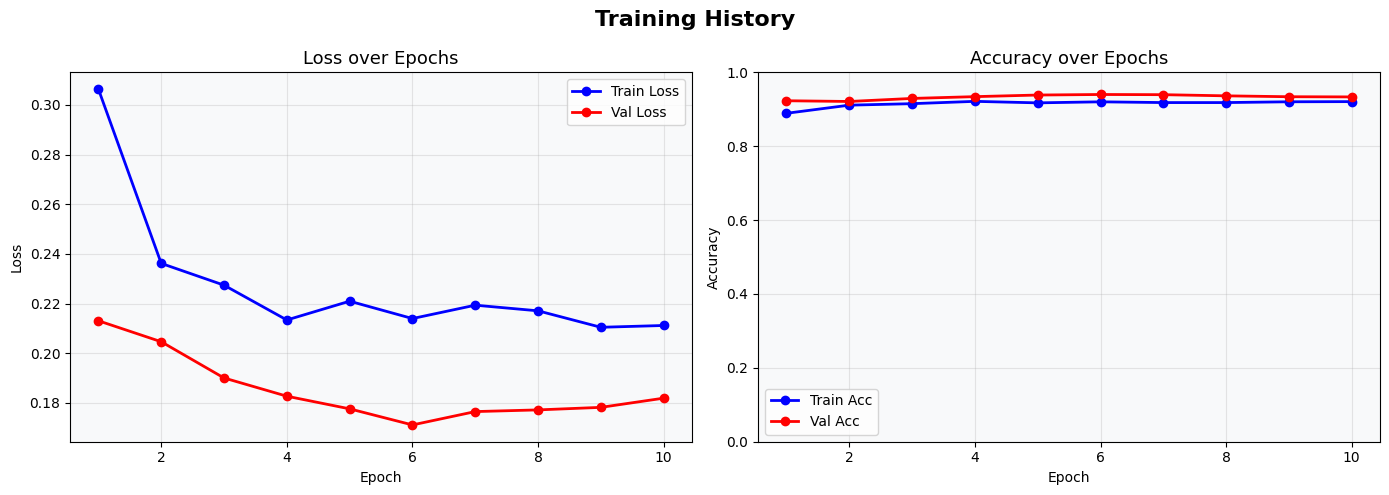

✅ Training history graph saved → training_history.png


In [13]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

axes[0].plot(epochs, history['train_loss'], 'b-o', linewidth=2, label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   'r-o', linewidth=2, label='Val Loss')
axes[0].set_title('Loss over Epochs',    fontsize=13)
axes[0].set_xlabel('Epoch');  axes[0].set_ylabel('Loss')
axes[0].legend();  axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#f8f9fa')

axes[1].plot(epochs, history['train_acc'], 'b-o', linewidth=2, label='Train Acc')
axes[1].plot(epochs, history['val_acc'],   'r-o', linewidth=2, label='Val Acc')
axes[1].set_title('Accuracy over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch');  axes[1].set_ylabel('Accuracy')
axes[1].legend();  axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#f8f9fa')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training history graph saved → training_history.png')

Evaluating: 100%|██████████| 87/87 [00:36<00:00,  2.42it/s]


📊 Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.94      0.92      0.93      1349
  Uninfected       0.93      0.95      0.94      1406

    accuracy                           0.94      2755
   macro avg       0.94      0.94      0.94      2755
weighted avg       0.94      0.94      0.94      2755



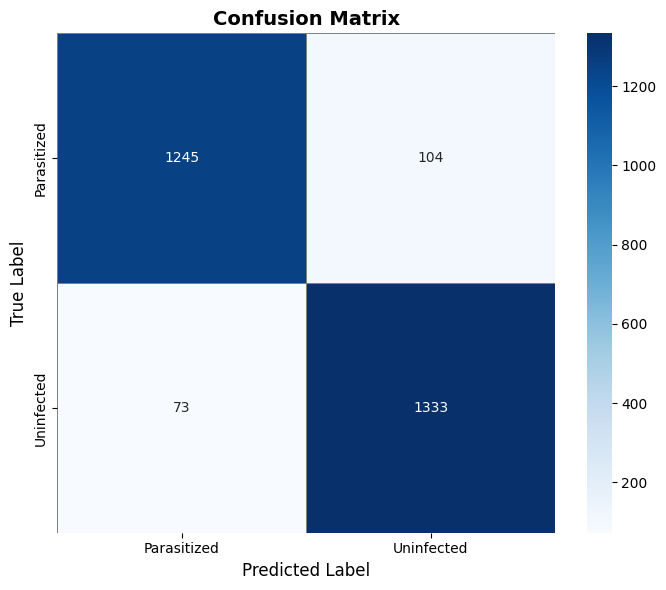

✅ Confusion matrix saved → confusion_matrix.png


In [14]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(loaders['test'], desc='Evaluating'):
        inputs = inputs.to(CONFIG['device'])
        preds  = model(inputs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('📊 Classification Report:')
print('=' * 50)
print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label',      fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved → confusion_matrix.png')

In [15]:
class GradCAM:
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None

        # Find the last CONV2D layer specifically (not Linear)
        self.target_layer = None
        for name, module in model.named_modules():
            if isinstance(module, torch.nn.Conv2d):
                self.target_layer = module
                self.target_name  = name

        print(f"✅ Hooking into Conv2d layer: {self.target_name}")

        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach().clone())
        )

    def _save_activation(self, module, input, output):
        self.activations = output.detach().clone()

    def generate(self, input_tensor):
        self.model.eval()
        self.gradients   = None
        self.activations = None

        # Enable gradient computation
        input_tensor = input_tensor.clone().requires_grad_(True)

        output   = self.model(input_tensor)
        pred_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, pred_idx].backward()

        # Use activation-based CAM (works even without gradient hooks)
        if self.activations is None:
            print("❌ Activations not captured.")
            return None, pred_idx

        # Compute CAM from activations directly (Class Activation Map)
        with torch.no_grad():
            # Get the weights from the classifier for this class
            try:
                # Try gradient-based approach first
                grads = torch.autograd.grad(
                    output[0, pred_idx],
                    self.activations,
                    retain_graph=True,
                    allow_unused=True
                )
                if grads[0] is not None:
                    weights = grads[0].mean(dim=(2, 3), keepdim=True)
                    cam = (weights * self.activations).sum(dim=1).squeeze()
                else:
                    raise ValueError("No gradients")
            except:
                # Fallback: use mean activation map
                cam = self.activations.mean(dim=1).squeeze()

        cam = cam.cpu().numpy()
        cam = np.maximum(cam, 0)

        if cam.max() == cam.min():
            cam = np.ones_like(cam) * 0.5
        else:
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, pred_idx


def visualize_gradcam(image_path):
    img          = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(CONFIG['device'])

    gradcam       = GradCAM(model)
    cam, pred_idx = gradcam.generate(input_tensor)

    if cam is None:
        print("❌ Grad-CAM failed. Skipping visualization.")
        return

    with torch.no_grad():
        confidence = torch.softmax(
            model(input_tensor), dim=1
        )[0][pred_idx].item() * 100

    cam_resized = np.array(
        Image.fromarray((cam * 255).astype(np.uint8)).resize((224, 224))
    ) / 255.0
    overlay = np.array(img.resize((224, 224))) / 255.0

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(
        f'Grad-CAM  |  Prediction: {classes[pred_idx]}  ({confidence:.1f}%)',
        fontsize=14, fontweight='bold'
    )
    axes[0].imshow(img)
    axes[0].set_title('Original Image'); axes[0].axis('off')
    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap'); axes[1].axis('off')
    axes[2].imshow(overlay)
    axes[2].imshow(cam_resized, cmap='jet', alpha=0.45)
    axes[2].set_title('AI Focus Overlay'); axes[2].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Prediction : {classes[pred_idx]}')
    print(f'   Confidence : {confidence:.1f}%')
    print(f'   Saved      : gradcam_result.png')

print("✅ GradCAM and visualize_gradcam both ready!")

✅ GradCAM and visualize_gradcam both ready!


🔴 Testing on a Parasitized cell:
✅ Hooking into Conv2d layer: features.8.0


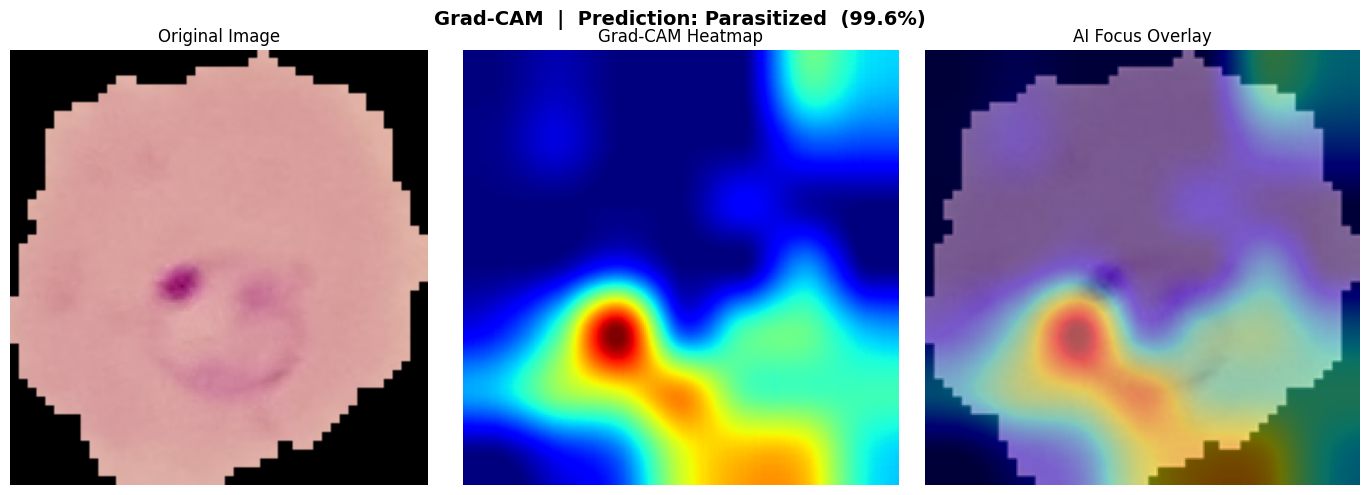

✅ Prediction : Parasitized
   Confidence : 99.6%
   Saved      : gradcam_result.png

🟢 Testing on an Uninfected cell:
✅ Hooking into Conv2d layer: features.8.0


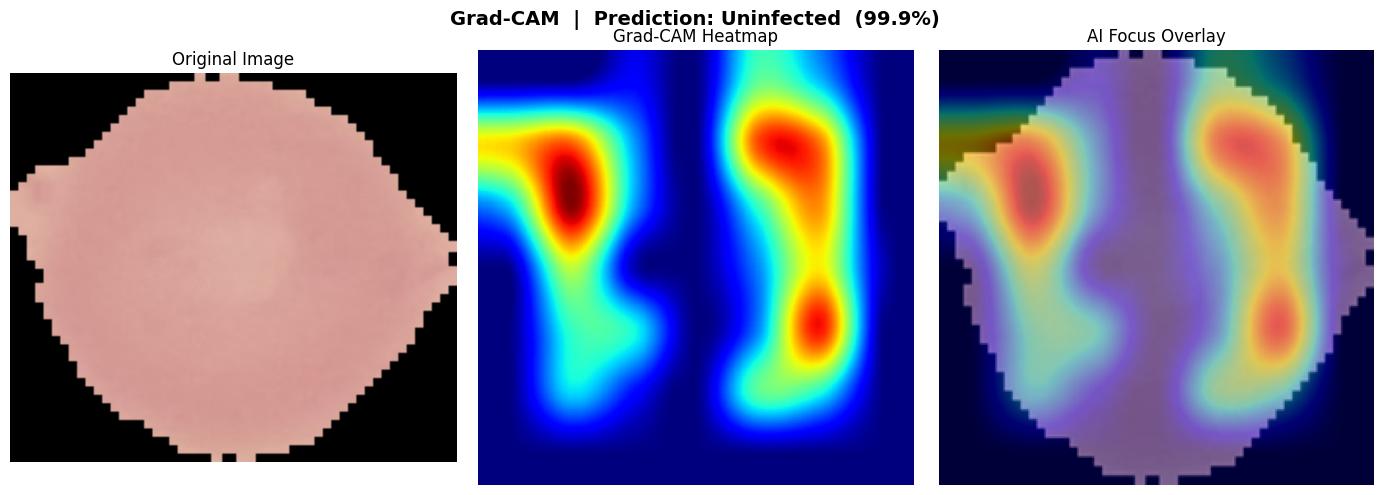

✅ Prediction : Uninfected
   Confidence : 99.9%
   Saved      : gradcam_result.png


In [16]:
import glob

parasitized_imgs = glob.glob(os.path.join(CONFIG['data_dir'], 'Parasitized', '*.png'))[:1]
uninfected_imgs  = glob.glob(os.path.join(CONFIG['data_dir'], 'Uninfected',  '*.png'))[:1]

if parasitized_imgs:
    print('🔴 Testing on a Parasitized cell:')
    visualize_gradcam(parasitized_imgs[0])

print()

if uninfected_imgs:
    print('🟢 Testing on an Uninfected cell:')
    visualize_gradcam(uninfected_imgs[0])
    

In [17]:
print('=' * 55)
print('  ✅  MALARIA CELL DETECTION — PROJECT COMPLETE!')
print('=' * 55)
print(f'  Best Validation Accuracy : {best_acc*100:.2f}%')
print(f'  Model saved              : {CONFIG["model_path"]}')
print()
print('  📁 Output files generated:')
output_files = [
    'malaria_model.pth     → Trained model weights',
    'training_history.png  → Loss & accuracy graphs',
    'confusion_matrix.png  → Test set evaluation',
    'gradcam_result.png    → Explainability heatmap',
    'sample_images.png     → Dataset preview',
]
for f in output_files:
    print(f'     {f}')
print()
print('=' * 55)

  ✅  MALARIA CELL DETECTION — PROJECT COMPLETE!
  Best Validation Accuracy : 94.00%
  Model saved              : malaria_model.pth

  📁 Output files generated:
     malaria_model.pth     → Trained model weights
     training_history.png  → Loss & accuracy graphs
     confusion_matrix.png  → Test set evaluation
     gradcam_result.png    → Explainability heatmap
     sample_images.png     → Dataset preview

